# Portfolio Optimization

Portfolio optimization turns expected returns, risk estimates, and constraints into allocation weights.

Abbreviations used in this notebook:

- **GMV**: Global Minimum Variance portfolio.
- **MSR**: Maximum Sharpe Ratio portfolio.
- **L1**: Sum of absolute weights, often used in constraint discussions.
- **CHF**: Swiss franc, used only as an illustrative currency.

## 1. Intuition

Optimization is a disciplined way to choose portfolio weights. The answer depends heavily on inputs and constraints. A mathematically optimal portfolio can still be practically bad if the expected returns are noisy or the constraints are unrealistic.

## 2. Mathematics

Minimum variance objective:

$$
\min_w w^T\Sigma w
$$

Maximum Sharpe objective:

$$
\max_w \frac{w^T\mu - r_f}{\sqrt{w^T\Sigma w}}
$$

Long-only constraints:

$$
w_i \ge 0, \quad \sum_i w_i = 1
$$

Maximum position constraint:

$$
w_i \le w_{max}
$$

## 3. Implementation

Without adding heavy optimization dependencies, we use a large random search over long-only portfolios and compare unconstrained versus max-weight-constrained results.

In [1]:
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "GUIDELINES.md").exists())
helper_path = project_root / "03_portfolio_management" / "portfolio_utils.py"
spec = importlib.util.spec_from_file_location("portfolio_utils", helper_path)
portfolio_utils = importlib.util.module_from_spec(spec)
spec.loader.exec_module(portfolio_utils)

plt.style.use("seaborn-v0_8-whitegrid")

returns = portfolio_utils.generate_synthetic_returns(periods=504, seed=321)
prices = portfolio_utils.returns_to_prices(returns)
assets = returns.columns.tolist()

expected_returns = portfolio_utils.annualized_return(returns)
covariance = returns.cov() * 252

all_weights = portfolio_utils.random_weights(len(assets), n_portfolios=30_000, seed=99)

def evaluate_weights(weight_matrix):
    rows = []
    for weight in weight_matrix:
        ret = portfolio_utils.portfolio_return(weight, expected_returns)
        vol = portfolio_utils.portfolio_volatility(weight, covariance)
        rows.append({"return": ret, "volatility": vol, "sharpe": portfolio_utils.sharpe_ratio(ret, vol, 0.015), **dict(zip(assets, weight))})
    return pd.DataFrame(rows)

results = evaluate_weights(all_weights)
constrained = results[(results[assets] <= 0.40).all(axis=1)].copy()
results.head()

,return,volatility,sharpe,Global Equity,Swiss Equity,Bonds,Real Estate,Commodities
0,0.033901,0.088707,0.213068,0.159625,0.178255,0.161481,0.306671,0.193968
1,0.034397,0.086015,0.225510,0.228487,0.115307,0.222949,0.187975,0.245283
2,0.055858,0.100935,0.404790,0.433345,0.114519,0.144118,0.182142,0.125877
3,0.048904,0.096850,0.350067,0.141172,0.377612,0.152413,0.312441,0.016362
4,0.034529,0.088124,0.221604,0.107490,0.252871,0.162771,0.320270,0.156598


In [2]:
solutions = pd.DataFrame({
    "Unconstrained MSR": results.loc[results["sharpe"].idxmax(), assets + ["return", "volatility", "sharpe"]],
    "Constrained MSR": constrained.loc[constrained["sharpe"].idxmax(), assets + ["return", "volatility", "sharpe"]],
    "Constrained GMV": constrained.loc[constrained["volatility"].idxmin(), assets + ["return", "volatility", "sharpe"]],
})

solutions.round(4)

,Unconstrained MSR,Constrained MSR,Constrained GMV
Global Equity,0.3123,0.3672,0.0255
Swiss Equity,0.0719,0.1618,0.2062
Bonds,0.5970,0.3862,0.3947
Real Estate,0.0158,0.0843,0.2580
Commodities,0.0031,0.0004,0.1156
return,0.0560,0.0615,0.0311
volatility,0.0635,0.0822,0.0665
sharpe,0.6463,0.5650,0.2427


## 4. Visualization

Optimization should be inspected visually. Constraints often reduce theoretical efficiency but create more realistic portfolios.

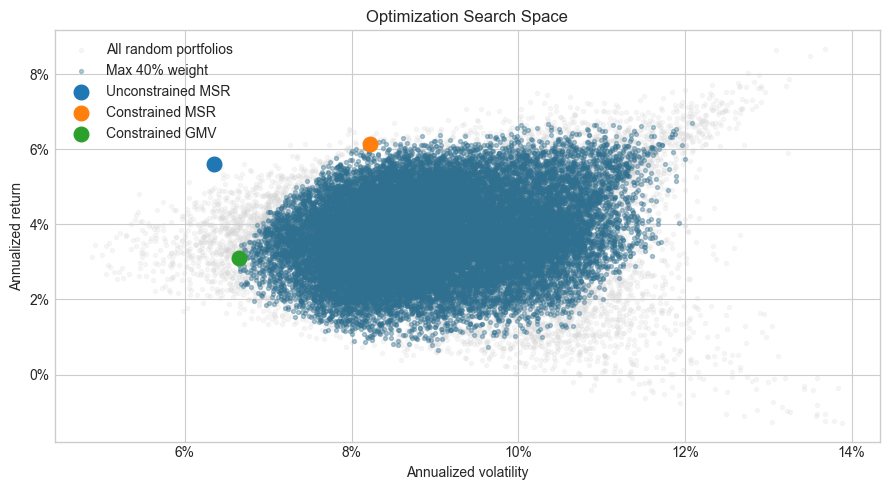

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(results["volatility"], results["return"], s=8, alpha=0.18, color="lightgray", label="All random portfolios")
ax.scatter(constrained["volatility"], constrained["return"], s=8, alpha=0.35, color="#2f6f8f", label="Max 40% weight")

for label, column in solutions.items():
    ax.scatter(column["volatility"], column["return"], s=110, label=label)

ax.set_title("Optimization Search Space")
ax.set_xlabel("Annualized volatility")
ax.set_ylabel("Annualized return")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.legend()
plt.tight_layout()
plt.show()

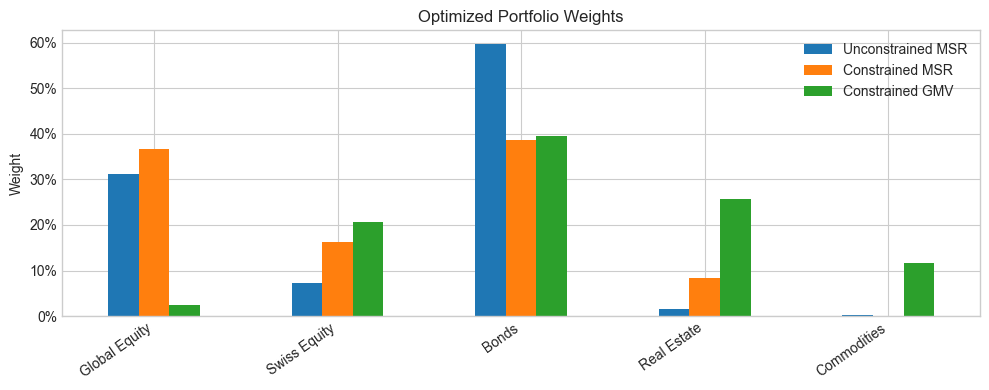

In [4]:
solutions.loc[assets].plot(kind="bar", figsize=(10, 4))
plt.title("Optimized Portfolio Weights")
plt.ylabel("Weight")
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 5. Application

Real portfolio optimization usually adds constraints: maximum weight, minimum weight, turnover limits, sector limits, tax constraints, liquidity limits, and no-short rules.

In [5]:
constraint_impact = pd.DataFrame({
    "unconstrained_msr": solutions["Unconstrained MSR"].loc[["return", "volatility", "sharpe"]],
    "constrained_msr": solutions["Constrained MSR"].loc[["return", "volatility", "sharpe"]],
    "constrained_gmv": solutions["Constrained GMV"].loc[["return", "volatility", "sharpe"]],
})

constraint_impact.round(4)

,unconstrained_msr,constrained_msr,constrained_gmv
return,0.0560,0.0615,0.0311
volatility,0.0635,0.0822,0.0665
sharpe,0.6463,0.5650,0.2427


## 6. Reflection

- Optimization is only as good as its assumptions.
- Expected returns are usually less stable than covariance estimates.
- Constraints make portfolios more realistic.
- A robust portfolio is often preferable to a fragile optimum.

Questions to answer after running the notebook:

1. How did the 40 percent max-weight constraint change allocations?
2. Which optimized portfolio would be easiest to explain to an investor?
3. Why can a maximum Sharpe portfolio be unstable?
4. What constraint would you add next?